In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openml 
import os
import warnings
import sys
from dotenv import load_dotenv

sys.path.append('..')
from src.data_loader import load_dataset_info


warnings.filterwarnings('ignore')
load_dotenv()

openml.config.apikey = os.getenv('OPENML_API_KEY')
openml.config.cache_directory = os.path.expanduser('~/.openml/cache')

# Load the enriched summary sheet
df = pd.read_csv('../results/dataset_summary_enriched.csv')


In [ ]:
#load_dataset_info(361055,"numerical_classification")

In [2]:
df.columns.tolist()

['task_id',
 'dataset_name',
 'suite_name',
 'task_type',
 'n_samples',
 'n_features',
 'n_categorical',
 'n_numerical',
 'n_classes',
 'has_missing',
 'dim_ratio',
 'size_bucket',
 'feature_bucket']

In [4]:
#Target Variable Analysis for Regression Datasets

reg_df = df[df['task_type'] == 'regression']
skewness_records = []

for _, row in reg_df.iterrows():
    info = load_dataset_info(int(row['task_id']), row['suite_name'])
    task = openml.tasks.get_task(int(row['task_id']))
    dataset = task.get_dataset()
    X, y, _, _ = dataset.get_data(target=task.target_name)
    
    y = pd.Series(y).astype(float)
    skew = y.skew()
    
    skewness_records.append({
        'dataset_name': row['dataset_name'],
        'skewness': skew
    })
    print(f"{row['dataset_name']:<40} skewness: {skew:.2f}")

skew_df = pd.DataFrame(skewness_records).sort_values('skewness', ascending=False)
skew_df.to_csv('../results/regression_target_skewness.csv', index=False)

cpu_act                                  skewness: -3.42
pol                                      skewness: 0.92
elevators                                skewness: 2.42
isolet                                   skewness: -0.00
wine_quality                             skewness: 0.19
Ailerons                                 skewness: -1.36
houses                                   skewness: -0.17
house_16H                                skewness: -3.43
diamonds                                 skewness: 0.12
Brazilian_houses                         skewness: 0.30
Bike_Sharing_Demand                      skewness: 1.28
nyc-taxi-green-dec-2016                  skewness: -0.00
house_sales                              skewness: 0.43
sulfur                                   skewness: 6.73
medical_charges                          skewness: 0.88
MiamiHousing2016                         skewness: 0.74
superconduct                             skewness: 0.86
california                               s

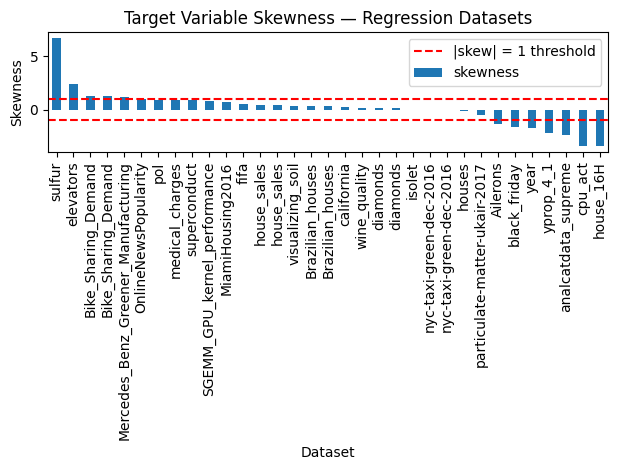

Highly skewed datasets (|skew| > 1): 13 out of 33
This confirms QuantileTransformer is essential for regression targets.


In [5]:
# Visualizing skewness across all regression datasets.

skew_df.plot(x='dataset_name', y='skewness', kind='bar')
plt.axhline(1,  color='red', linestyle='--', label='|skew| = 1 threshold')
plt.axhline(-1, color='red', linestyle='--')
plt.title('Target Variable Skewness — Regression Datasets')
plt.xlabel('Dataset')
plt.ylabel('Skewness')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.savefig('../results/target_skewness.png', dpi=150, bbox_inches='tight')
plt.show()

# Summarize how many datasets fall into each skewness category
highly_skewed = (skew_df['skewness'].abs() > 1).sum()
print(f"Highly skewed datasets (|skew| > 1): {highly_skewed} out of {len(skew_df)}")
print(f"This confirms QuantileTransformer is essential for regression targets.")

skew_df.to_csv('../results/target_skewness.csv', index=False)

In [6]:
# Class balance check for classification datasets.

clf_df = df[df['task_type'] == 'classification']
balance_records = []

for _, row in clf_df.iterrows():
    task    = openml.tasks.get_task(int(row['task_id']))
    dataset = task.get_dataset()
    X, y, _, _ = dataset.get_data(target=task.target_name)
    
    y = pd.Series(y)
    majority_pct = y.value_counts(normalize=True).max() * 100
    
    balance_records.append({
        'dataset_name': row['dataset_name'],
        'suite_name':   row['suite_name'],
        'majority_pct': majority_pct
    })
    print(f"{row['dataset_name']:<40} majority class: {majority_pct:.1f}%")

balance_df = pd.DataFrame(balance_records).sort_values('majority_pct', ascending=False)
balance_df.to_csv('../results/class_balance.csv', index=False)

credit                                   majority class: 50.0%
california                               majority class: 50.0%
wine                                     majority class: 50.0%
electricity                              majority class: 50.0%
covertype                                majority class: 50.0%
pol                                      majority class: 50.0%
house_16H                                majority class: 50.0%
kdd_ipums_la_97-small                    majority class: 50.0%
MagicTelescope                           majority class: 50.0%
bank-marketing                           majority class: 50.0%
phoneme                                  majority class: 50.0%
MiniBooNE                                majority class: 50.0%
Higgs                                    majority class: 50.0%
eye_movements                            majority class: 50.0%
jannis                                   majority class: 50.0%
electricity                              majority class

In [7]:
# Correlation structure analysis

correlation_records = []

for _, row in df.iterrows():
    task    = openml.tasks.get_task(int(row['task_id']))
    dataset = task.get_dataset()
    X, y, cat_indicator, attr_names = dataset.get_data(target=task.target_name)
    X = pd.DataFrame(X, columns=attr_names)
    
    # Only using numerical columns since correlation is not meaningful for categoricals
    num_cols = [col for col, is_cat in zip(attr_names, cat_indicator) if not is_cat]
    X_num = X[num_cols].select_dtypes(include=[np.number]).dropna(axis=1)
    
    if X_num.shape[1] > 1:
        # Compute absolute correlation matrix and take upper triangle only
        # to avoid counting each pair twice
        corr_matrix = X_num.corr().abs()
        upper = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )
        avg_corr = upper.stack().mean()
    else:
        avg_corr = 0.0
    
    correlation_records.append({
        'dataset_name': row['dataset_name'],
        'suite_name':   row['suite_name'],
        'avg_correlation': round(avg_corr, 4)
    })
    print(f"{row['dataset_name']:<40} avg correlation: {avg_corr:.4f}")

corr_df = pd.DataFrame(correlation_records).sort_values('avg_correlation', ascending=False)

credit                                   avg correlation: 0.1305
california                               avg correlation: 0.1325
wine                                     avg correlation: 0.2413
electricity                              avg correlation: 0.2125
covertype                                avg correlation: 0.1932
pol                                      avg correlation: 0.0953
house_16H                                avg correlation: 0.1547
kdd_ipums_la_97-small                    avg correlation: 0.3812
MagicTelescope                           avg correlation: 0.2741
bank-marketing                           avg correlation: 0.0607
phoneme                                  avg correlation: 0.1197
MiniBooNE                                avg correlation: 0.8071
Higgs                                    avg correlation: 0.0748
eye_movements                            avg correlation: 0.1247
jannis                                   avg correlation: 0.0526
cpu_act                  

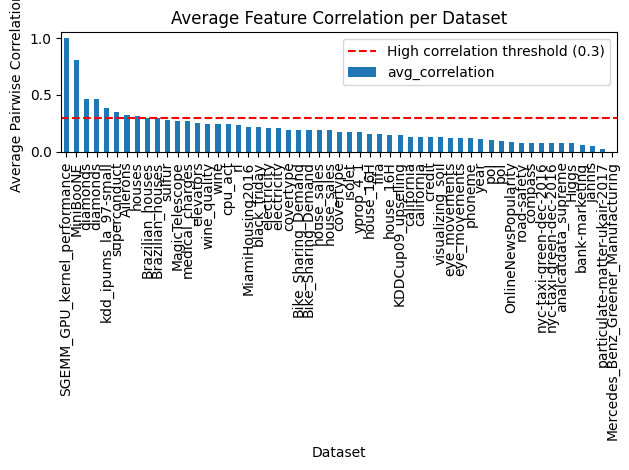

In [8]:
# Visualizing  correlation structure across all datasets

corr_df.plot(x='dataset_name', y='avg_correlation', kind='bar')
plt.axhline(0.3, color='red', linestyle='--', label='High correlation threshold (0.3)')
plt.title('Average Feature Correlation per Dataset')
plt.xlabel('Dataset')
plt.ylabel('Average Pairwise Correlation')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.savefig('../results/correlation_structure.png', dpi=150, bbox_inches='tight')
plt.show()

corr_df.to_csv('../results/correlation_structure.csv', index=False)

In [9]:
# Merging correlation scores with dataset metadata

corr_df['correlation_bucket'] = pd.cut(
    corr_df['avg_correlation'],
    bins=[0, 0.2, 0.4, 1.0],
    labels=['low (0-0.2)', 'medium (0.2-0.4)', 'high (>0.4)']
)

print("Datasets per correlation bucket:")
print(corr_df['correlation_bucket'].value_counts().sort_index())


# These are the ones we predict will show the largest tree vs DL gap
high_corr = corr_df[corr_df['avg_correlation'] > 0.4]
print(f"\nHigh correlation datasets (predicted tree advantage):")
print(high_corr[['dataset_name', 'avg_correlation']].to_string(index=False))

Datasets per correlation bucket:
correlation_bucket
low (0-0.2)         32
medium (0.2-0.4)    18
high (>0.4)          4
Name: count, dtype: int64

High correlation datasets (predicted tree advantage):
                dataset_name  avg_correlation
SGEMM_GPU_kernel_performance           1.0000
                   MiniBooNE           0.8071
                    diamonds           0.4642
                    diamonds           0.4642


In [11]:
# Outlier analysis — what percentage of samples have at least one feature value beyond 3 standard deviations from the mean?
outlier_records = []

for _, row in df.iterrows():
    task    = openml.tasks.get_task(int(row['task_id']))
    dataset = task.get_dataset()
    X, y, cat_indicator, attr_names = dataset.get_data(target=task.target_name)
    X = pd.DataFrame(X, columns=attr_names)
    
    # Only check numerical features — outliers in categoricals don't apply
    num_cols = [col for col, is_cat in zip(attr_names, cat_indicator) if not is_cat]
    X_num = X[num_cols].select_dtypes(include=[np.number]).dropna(axis=1)
    
    if X_num.shape[1] > 0:
        # Compute z-scores for every value in every numerical column
        z_scores = (X_num - X_num.mean()) / (X_num.std() + 1e-8)
        
        # A sample is flagged as an outlier if ANY of its features
        # exceeds 3 standard deviations and we use .any(axis=1) for this
        outlier_pct = (z_scores.abs() > 3).any(axis=1).mean() * 100
    else:
        outlier_pct = 0.0
    
    outlier_records.append({
        'dataset_name': row['dataset_name'],
        'suite_name':   row['suite_name'],
        'outlier_pct':  round(outlier_pct, 2)
    })
    print(f"{row['dataset_name']:<40} outlier samples: {outlier_pct:.1f}%")

outlier_df = pd.DataFrame(outlier_records).sort_values('outlier_pct', ascending=False)

credit                                   outlier samples: 5.4%
california                               outlier samples: 4.1%
wine                                     outlier samples: 8.0%
electricity                              outlier samples: 1.3%
covertype                                outlier samples: 7.7%
pol                                      outlier samples: 35.5%
house_16H                                outlier samples: 15.5%
kdd_ipums_la_97-small                    outlier samples: 8.9%
MagicTelescope                           outlier samples: 6.7%
bank-marketing                           outlier samples: 9.4%
phoneme                                  outlier samples: 3.3%
MiniBooNE                                outlier samples: 5.4%
Higgs                                    outlier samples: 13.2%
eye_movements                            outlier samples: 15.6%
jannis                                   outlier samples: 27.1%
cpu_act                                  outlier s

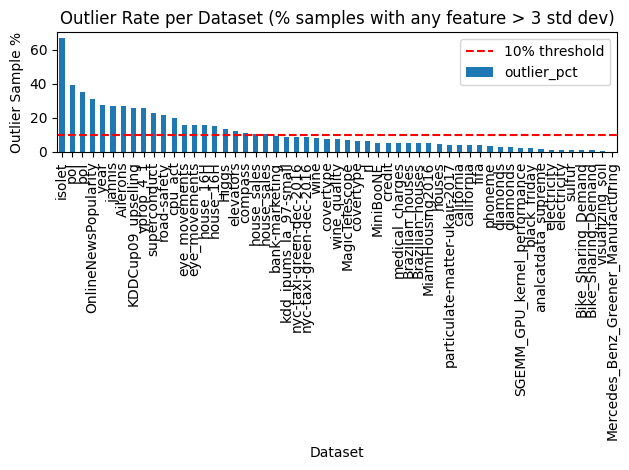

Datasets with outlier rate > 10%: 21
This is strongly justifies that to use  QuantileTransformer over StandardScaler.


In [12]:
# Visualizing  outlier rates across all datasets
outlier_df.plot(x='dataset_name', y='outlier_pct', kind='bar')
plt.axhline(10, color='red', linestyle='--', label='10% threshold')
plt.title('Outlier Rate per Dataset (% samples with any feature > 3 std dev)')
plt.xlabel('Dataset')
plt.ylabel('Outlier Sample %')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.savefig('../results/outlier_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Save for later use in results analysis
outlier_df.to_csv('../results/outlier_analysis.csv', index=False)
print(f"Datasets with outlier rate > 10%: {(outlier_df['outlier_pct'] > 10).sum()}")
print("This is strongly justifies that to use  QuantileTransformer over StandardScaler.")

In [ ]:
# Difficult Estimation 

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder, QuantileTransformer

difficulty_records = []

for _, row in df.iterrows():
    task    = openml.tasks.get_task(int(row['task_id']))
    dataset = task.get_dataset()
    X, y, cat_indicator, attr_names = dataset.get_data(target=task.target_name)
    X = pd.DataFrame(X, columns=attr_names)
    
    # Use only numerical features for the baseline —
    # we want a simple, fair comparison across all datasets
    # without worrying about encoding strategies for categoricals
    num_cols = [col for col, is_cat in zip(attr_names, cat_indicator) if not is_cat]
    X_num = X[num_cols].select_dtypes(include=[np.number]).fillna(0)
    
    if X_num.shape[1] == 0:
        print(f"{row['dataset_name']:<40} skipping — there are no numerical features")
        continue
    
    # Cap at 5000 samples for speed — we don't need the full dataset
    # to get a rough difficulty estimate
    if len(X_num) > 5000:
        idx   = np.random.RandomState(42).choice(len(X_num), 5000, replace=False)
        X_num = X_num.iloc[idx]
        y_sub = pd.Series(y).iloc[idx]
    else:
        y_sub = pd.Series(y)
    
    # Apply QuantileTransformer so the baseline model 
    qt = QuantileTransformer(output_distribution='normal', random_state=42)
    X_scaled = qt.fit_transform(X_num)
    
    if row['task_type'] == 'classification':
        le    = LabelEncoder()
        y_enc = le.fit_transform(y_sub.astype(str))
        model = LogisticRegression(max_iter=500, random_state=42)
        # ROC-AUC is our chosen metric for classification
        score = cross_val_score(model, X_scaled, y_enc, cv=3,
                                scoring='roc_auc').mean()
        metric = 'roc_auc'
    else:
        y_enc = y_sub.astype(float)
        model = Ridge()
        # R² for regression — tells us how much variance the baseline explains
        score = cross_val_score(model, X_scaled, y_enc, cv=3,
                                scoring='r2').mean()
        metric = 'r2'
    
    difficulty_records.append({
        'dataset_name':   row['dataset_name'],
        'suite_name':     row['suite_name'],
        'task_type':      row['task_type'],
        'baseline_score': round(score, 4),
        'metric':         metric
    })
    print(f"{row['dataset_name']:<40} baseline {metric}: {score:.4f}")

diff_df = pd.DataFrame(difficulty_records)

credit                                   baseline roc_auc: 0.8368
california                               baseline roc_auc: 0.9090
wine                                     baseline roc_auc: 0.7123
electricity                              baseline roc_auc: 0.8184
covertype                                baseline roc_auc: 0.7081
pol                                      baseline roc_auc: 0.7581
house_16H                                baseline roc_auc: 0.9074
kdd_ipums_la_97-small                    baseline roc_auc: 0.9443
MagicTelescope                           baseline roc_auc: 0.8612
bank-marketing                           baseline roc_auc: 0.8486
phoneme                                  baseline roc_auc: 0.7850
MiniBooNE                                baseline roc_auc: 0.9599
Higgs                                    baseline roc_auc: 0.6559
eye_movements                            baseline roc_auc: 0.6100
jannis                                   baseline roc_auc: 0.8094
cpu_act   

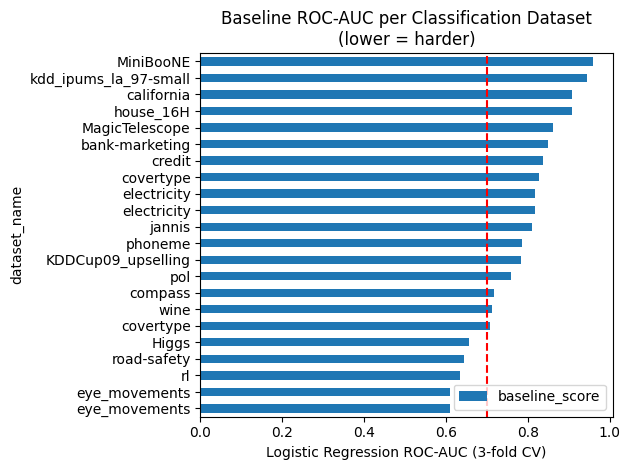

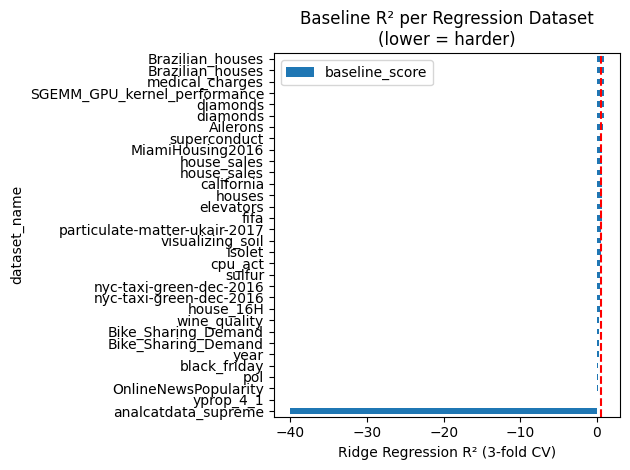


Classification — hard datasets (ROC-AUC < 0.7): 5
Regression — hard datasets (R² < 0.3): 9


In [14]:
# visualization
clf_diff = diff_df[diff_df['task_type'] == 'classification'].sort_values('baseline_score')
reg_diff = diff_df[diff_df['task_type'] == 'regression'].sort_values('baseline_score')

# Classification difficulty
clf_diff.plot(x='dataset_name', y='baseline_score', kind='barh')
plt.axvline(0.7, color='red', linestyle='--', label='Moderate difficulty threshold')
plt.title('Baseline ROC-AUC per Classification Dataset\n(lower = harder)')
plt.xlabel('Logistic Regression ROC-AUC (3-fold CV)')
plt.tight_layout()
plt.savefig('../results/difficulty_classification.png', dpi=150, bbox_inches='tight')
plt.show()

# Regression difficulty
reg_diff.plot(x='dataset_name', y='baseline_score', kind='barh')
plt.axvline(0.5, color='red', linestyle='--', label='Moderate difficulty threshold')
plt.title('Baseline R² per Regression Dataset\n(lower = harder)')
plt.xlabel('Ridge Regression R² (3-fold CV)')
plt.tight_layout()
plt.savefig('../results/difficulty_regression.png', dpi=150, bbox_inches='tight')
plt.show()

# Saving for merging with benchmark results later
diff_df.to_csv('../results/difficulty_scores.csv', index=False)

# Quick summary
print(f"\nClassification — hard datasets (ROC-AUC < 0.7): {(clf_diff['baseline_score'] < 0.7).sum()}")
print(f"Regression — hard datasets (R² < 0.3): {(reg_diff['baseline_score'] < 0.3).sum()}")